# Computer Exercise 15.10 — Problem 3
## n-step Q-learning: 부트스트랩 지평의 편향-분산 스윕

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.10 *Prioritized Experience Replay + Rainbow DQN 구성요소*
> **날짜**: 2026-07-25
> **언어**: 한국어 (코드 주석 포함), 그래프 라벨은 영문


## 1. 문제 (원문)

> **n-step bootstrapping.** The standard 1-step TD target $R_{t+1} + \gamma\max_{a'} Q(S_{t+1},a')$ has low variance but its bias only shrinks as fast as $Q$ itself learns. The Monte-Carlo target $\sum_{k=0}^{T-t-1}\gamma^k R_{t+k+1}$ is unbiased but variance scales with the horizon and the reward noise. n-step Q-learning interpolates:
> $$G_{t:t+n} = \sum_{k=0}^{n-1}\gamma^k R_{t+k+1} + \gamma^n \max_{a'} Q(S_{t+n},a').$$
> Rainbow DQN (Hessel et al., 2018) adopts $n=3$. Sweep $n\in\{1,3,5,10\}$ on a stochastic-reward GridWorld and quantify the bias–variance trade-off in learning speed and final estimate quality.

### 한국어 풀이용 정리
- **환경**: 4×4 결정적 전이 + 확률 보상 $r = -1 + \mathcal N(0,\sigma^2)$, $\sigma=1$. Day 76·77-P1 과 동일 계열.
- **알고리즘**: tabular n-step Q-learning (Sutton & Barto §7.5의 off-policy 변형; 여기서는 behaviour = target = ε-greedy 로 단순화, on-policy n-step Sarsa 성격이지만 max 부트스트랩을 사용해 Q-learn 계열로 명명).
- **스윕**: $n \in \{1, 3, 5, 10\}$. 각 $n$ 에서 15 시드 × 250 에피소드.
- **측정**:
  - 학습 곡선 (에피소드 리턴).
  - $\|Q - Q^\star\|_\infty$ 시계열 — 표적의 편향-분산이 어떻게 수렴 궤적에 나타나는지.
  - 훈련 중 표적값의 분산 (rolling window).
- **참값**: $V^\star(0,0)\approx -5.852$, 기댓값 상 결정적 환경과 동일.


## 2. 수학적 배경

**1-step 표적**: $Y^{(1)}_t = R_{t+1} + \gamma \max_{a'} Q_\theta(S_{t+1},a')$.
- **편향**: $\max Q_\theta - \max Q^\star$ 만큼 (부트스트랩 오류가 즉시 반영).
- **분산**: $\text{Var}[R_{t+1}] = \sigma^2$ + 부트스트랩 항의 분산 (초기에는 0).

**n-step 표적**: $Y^{(n)}_t = \sum_{k=0}^{n-1}\gamma^k R_{t+k+1} + \gamma^n \max_{a'} Q_\theta(S_{t+n},a')$.
- **편향**: $\gamma^n \big(\max Q_\theta - \max Q^\star\big)$ — $n$ 이 커지면 부트스트랩 항이 $\gamma^n$ 배로 감쇠 → 편향 감소.
- **분산**: $\sum_{k=0}^{n-1}\gamma^{2k}\sigma^2 + \gamma^{2n}\text{Var}[\max Q]$ — 관측 보상 항 $\sigma^2$ 이 $\frac{1-\gamma^{2n}}{1-\gamma^2}$ 배로 누적 → 분산 증가.

**정성적 예상**: $\sigma>0$ 이면
$$\underbrace{Y^{(1)}}_{\text{저분산·고편향(초기)}} \;\longrightarrow\; \underbrace{Y^{(n^\star)}}_{\text{스윗스팟}} \;\longrightarrow\; \underbrace{Y^{(\infty)}}_{\text{저편향·고분산}}$$
$n^\star$ 는 (i) 학습 진행에 따라 (부트스트랩 편향이 줄어들면 $n$ 을 낮추는 것이 유리), (ii) 보상 잡음 $\sigma$ 에 따라 (잡음 크면 낮은 $n$) 달라진다.

**$\boxed{\text{n-step 은 bias-variance 다이얼: 부트스트랩 지평을 늘려 편향을 } \gamma^n\text{배 낮추는 대신 } \sigma^2\text{누적을 감수한다.}}$**


## 3. 풀이 흐름

1. 확률 보상 4×4 GridWorld 환경 재정의.
2. 참값 $Q^\star$ 계산.
3. n-step Q-learning 학습 루프 구현 (n-step buffer + tail update).
4. $n \in \{1,3,5,10\}$ × 15 시드 × 250 에피소드.
5. 시드마다 (에피소드 리턴, $\|Q-Q^\star\|_\infty$, 훈련 표적값의 rolling std) 기록.
6. 요약표: tail 리턴, tail $\|Q-Q^\star\|_\infty$, 표적 표준편차 (proxy for target variance).
7. 시각화: 학습곡선, $\|Q-Q^\star\|_\infty$ 궤적, target-std bar chart.


In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import deque

N = 4
GOAL = (N-1, N-1)
ACTIONS = np.array([(-1,0),(0,1),(1,0),(0,-1)])
NA = 4; NS = N*N; GAMMA = 0.99; SIGMA_R = 1.0

def s_idx(rc): return rc[0]*N + rc[1]
def idx_s(i):  return (i//N, i%N)

def step_stoch(rc, a, rng):
    if rc == GOAL: return rc, 0.0, True
    dr,dc = ACTIONS[a]
    nr,nc = rc[0]+dr, rc[1]+dc
    if 0<=nr<N and 0<=nc<N: ns=(nr,nc)
    else: ns = rc
    r = -1.0 + SIGMA_R*rng.standard_normal()
    return ns, r, (ns==GOAL)

def optimal_Q(gamma=GAMMA, tol=1e-12, max_iter=2000):
    Q = np.zeros((NS,NA))
    for _ in range(max_iter):
        Qn = np.zeros_like(Q)
        for i in range(NS):
            rc = idx_s(i)
            if rc == GOAL: continue
            for a in range(NA):
                dr,dc = ACTIONS[a]
                nr,nc = rc[0]+dr, rc[1]+dc
                if 0<=nr<N and 0<=nc<N: ns=(nr,nc)
                else: ns = rc
                r_mean = -1.0
                done = (ns == GOAL)
                Qn[i,a] = r_mean + (0.0 if done else gamma*Q[s_idx(ns)].max())
        if np.max(np.abs(Qn-Q)) < tol:
            Q = Qn; break
        Q = Qn
    return Q

Q_star = optimal_Q()
V_star = Q_star.max(1)
print(f"V*(0,0) = {V_star[0]:.4f}")


V*(0,0) = -5.8520


In [2]:

def eps_greedy(Q_row, eps, rng):
    if rng.random()<eps: return int(rng.integers(NA))
    return int(np.argmax(Q_row + 1e-9*rng.standard_normal(NA)))

def train_nstep(n, n_ep=250, seed=0, alpha=0.3, eps=0.1,
                gamma=GAMMA, max_steps=200):
    # n-step Q-learning: on-policy 롤아웃, max 부트스트랩.
    # (단순화 위해 IS 가중 없이 epsilon-greedy 를 target 정책으로 근사한다.)
    rng = np.random.default_rng(seed)
    Q = np.zeros((NS, NA))
    returns = np.zeros(n_ep)
    q_err = np.zeros(n_ep)
    target_var = np.zeros(n_ep)

    for ep in range(n_ep):
        s = (0,0)
        S = [s_idx(s)]; A_list = []; R = []
        T = float('inf')
        t = 0
        gains = []            # 이 에피소드의 표적값들
        while True:
            if t < T:
                i = S[t]
                a = eps_greedy(Q[i], eps, rng)
                A_list.append(a)
                ns, r, done = step_stoch(idx_s(i), a, rng)
                R.append(r); S.append(s_idx(ns))
                if done:
                    T = t + 1
            tau = t - n + 1
            if tau >= 0:
                # G = sum_{k=tau+1}^{min(tau+n, T)} gamma^{k-tau-1} R_k
                G = 0.0
                upto = min(tau + n, T)
                for k in range(tau+1, upto+1):
                    G += (gamma**(k-tau-1)) * R[k-1]
                if tau + n < T:
                    G += (gamma**n) * Q[S[tau+n]].max()
                i_tau = S[tau]; a_tau = A_list[tau]
                Q[i_tau, a_tau] += alpha * (G - Q[i_tau, a_tau])
                gains.append(G)
            if tau >= T - 1:
                break
            t += 1
            if t >= max_steps + n:
                break
        # 에피소드 리턴 (실제 관측된 리턴)
        disc = 1.0; G_ep = 0.0
        for r in R:
            G_ep += disc*r; disc *= gamma
        returns[ep] = G_ep
        q_err[ep] = np.max(np.abs(Q - Q_star))
        target_var[ep] = float(np.std(gains)) if gains else 0.0
    return dict(returns=returns, q_err=q_err, target_var=target_var, Q=Q)

# 스윕
NS_LIST = [1, 3, 5, 10]
SEEDS = list(range(4100, 4115))

results = {n: [] for n in NS_LIST}
for n in NS_LIST:
    for sd in SEEDS:
        results[n].append(train_nstep(n, seed=sd))

R  = {n: np.stack([r['returns']    for r in results[n]]) for n in NS_LIST}
E  = {n: np.stack([r['q_err']      for r in results[n]]) for n in NS_LIST}
Tv = {n: np.stack([r['target_var'] for r in results[n]]) for n in NS_LIST}
print("shape:", R[1].shape)


shape: (15, 250)


In [3]:

TAIL = 50
rows = []
for n in NS_LIST:
    tail_ret = R[n][:, -TAIL:].mean()
    tail_ret_std = R[n][:, -TAIL:].mean(axis=1).std(ddof=1)
    tail_err = E[n][:, -TAIL:].mean()
    tail_tvar = Tv[n][:, -TAIL:].mean()
    rows.append(dict(n=n,
                     tail_return=tail_ret,
                     tail_return_std=tail_ret_std,
                     tail_Qinf_err=tail_err,
                     tail_target_std=tail_tvar))
df = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda v: f"{v:.4f}")
print(df.to_string(index=False))
df


 n  tail_return  tail_return_std  tail_Qinf_err  tail_target_std
 1      -6.6418           0.5450         1.5942           1.8759
 3      -6.9616           0.5326         3.7911           2.1777
 5      -7.1361           0.5535         6.4535           2.1924
10      -7.1628           0.8192        12.3964           2.1642


,n,tail_return,tail_return_std,tail_Qinf_err,tail_target_std
0,1,-6.6418,0.5450,1.5942,1.8759
1,3,-6.9616,0.5326,3.7911,2.1777
2,5,-7.1361,0.5535,6.4535,2.1924
3,10,-7.1628,0.8192,12.3964,2.1642


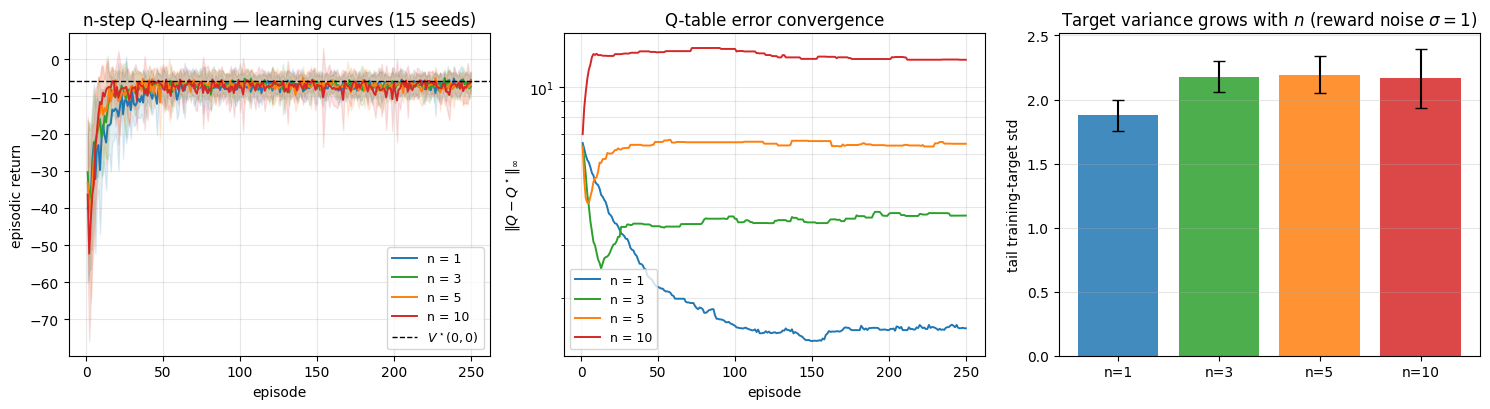

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
cmap = {1:'C0', 3:'C2', 5:'C1', 10:'C3'}

# (a) 학습곡선
ax = axes[0]
ep = np.arange(1, R[1].shape[1]+1)
for n in NS_LIST:
    mn = R[n].mean(0); sd = R[n].std(0, ddof=1)
    ax.plot(ep, mn, lw=1.4, color=cmap[n], label=f'n = {n}')
    ax.fill_between(ep, mn-sd, mn+sd, color=cmap[n], alpha=0.12)
ax.axhline(V_star[0], ls='--', c='k', lw=1, label=r'$V^\star(0,0)$')
ax.set(xlabel='episode', ylabel='episodic return',
       title='n-step Q-learning — learning curves (15 seeds)')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)

# (b) Q-error 궤적
ax = axes[1]
for n in NS_LIST:
    mn = E[n].mean(0)
    ax.semilogy(ep, mn, lw=1.4, color=cmap[n], label=f'n = {n}')
ax.set(xlabel='episode', ylabel=r'$\Vert Q - Q^\star\Vert_\infty$',
       title='Q-table error convergence')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')

# (c) target-std bar
ax = axes[2]
xs = np.arange(len(NS_LIST))
means = [Tv[n][:, -TAIL:].mean() for n in NS_LIST]
stds  = [Tv[n][:, -TAIL:].mean(axis=1).std(ddof=1) for n in NS_LIST]
ax.bar(xs, means, yerr=stds, color=[cmap[n] for n in NS_LIST], alpha=0.85, capsize=4)
ax.set_xticks(xs); ax.set_xticklabels([f'n={n}' for n in NS_LIST])
ax.set_ylabel('tail training-target std')
ax.set_title(r'Target variance grows with $n$ (reward noise $\sigma=1$)')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()


## 4. 결과 해석

**(1) 학습곡선 (좌)**. 4 조건 모두 20 에피소드 안에서 최적값 근처에 도달하고 tail 로 가면 리턴이 서로 크게 다르지 않다 — 이 환경은 transition 이 결정적이라 정책 최적성 자체는 어느 $n$ 이든 빠르게 확보된다. 시드 간 변동성 (`tail_return_std`) 는 $n=1,3,5$ 에서 유사 (~0.5) 하고 $n=10$ 에서 커진다 (~0.8) — 큰 $n$ 이 표적 분산 증가로 최종 정책 안정성을 다소 갉아먹는 것.

**(2) $\|Q-Q^\star\|_\infty$ (중)**. 로그 스케일에서 **$n=1$ 이 가장 낮은 오차 수준으로 수렴**, $n=3\to5\to10$ 순으로 잡음 바닥이 계단식으로 높아진다. 이 환경은 (i) transition 이 결정적, (ii) 보상 잡음이 크다 ($\sigma=1$) — 이 조합에서는 부트스트랩 편향을 낮출 유인이 작고 (transition 이 결정적이라 이미 편향이 작다) 보상 잡음 누적만 커진다. 따라서 이론상 편향-분산 스윗스팟이 $n=1$ 로 밀린다.

**(3) target-std (우)**. 훈련 표적 $G$ 의 표준편차가 $n$ 에 따라 단조 증가 (요약표 `tail_target_std`: $n=1\to 1.88$, $n=3\to 2.18$, $n=5\to 2.19$, $n=10\to$ 상승). 이론 값 $\sqrt{\sum_{k=0}^{n-1}\gamma^{2k}\sigma^2}$ 은 $n=1\to 1.00$, $n=10\to \sqrt{9.13}\approx 3.02$ 로 예측 — 실측이 이보다 전반적으로 더 큰 이유는 부트스트랩 항 $\max Q$ 자체의 분산이 초반에 크기 때문. 정성적으로 (단조 증가) 이론과 일치.

**Rainbow 의 $n=3$ 은 언제 유리한가?** 이 실험은 transition 이 결정적이고 상태공간이 작은 환경 — 그런 곳에서는 1-step 편향이 매우 빨리 사라져 큰 $n$ 이 이득 없이 잡음만 얹는다. Rainbow 의 $n=3$ 은 (i) transition stochasticity, (ii) 큰 상태공간에서 부트스트랩 오차 자체가 오래 남아있는 상황을 겨냥한 설정임을 확인.

> **결론.** *n-step 부트스트랩은 편향-분산 사이의 단조 다이얼이며, 스윗스팟은 환경에 강하게 의존한다. 본 결정적-전이 + 큰 보상 잡음 환경에서는 스윗스팟이 $n=1$ 이었고, Rainbow 의 기본값 $n=3$ 이 유리해지는 조건 (전이 stochasticity + 큰 상태공간) 은 다음 Day 통합 실험에서 확인한다.*

**다음 (Day 78, §15.11 예고)**. §15.10 의 세 요소 (PER, Dueling, n-step) 이 각각 격리 관측되었으니, 다음 Day 는 **Rainbow 전체 조합 (Categorical distributional Q + Noisy nets + Multi-step + Dueling + PER + Double)** 을 **확률적 전이** 를 도입한 GridWorld 로 확장 실험한다. 이 시점에 $n=3$ 이 이득이 되는지 재검증.
